<a href="https://colab.research.google.com/github/adi542/ai-ml/blob/main/text_classification_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q huggingface_hub

In [2]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
from huggingface_hub import list_datasets
all_datasets = list(list_datasets(limit=100))
print(len(all_datasets))

100


In [4]:
print(all_datasets[:10])

[DatasetInfo(id='openbmb/UltraData-SFT-2605', author='openbmb', card_data=None, citation=None, created_at=datetime.datetime(2026, 5, 21, 7, 28, 49, tzinfo=datetime.timezone.utc), description='\n\t\n\t\t\n\t\n\t\n\t\tUltraData-SFT-2605\n\t\n\n\n  \n\n\n\n📦 UltraData Collection |\n🌐 UltraData | \n🤗 MiniCPM5 Series\n\n\n\nEnglish |\n中文\n\n\n\n\t\n\t\t\n\t\n\t\n\t\t📚 Introduction\n\t\n\nUltraData-SFT-2605 is the full set of core-domain SFT data used in the post-training of MiniCPM5-1B-SFT within the MiniCPM5-1B series, and a key representative of L3 refined data in the UltraData L0-L4 tiered data management framework. It covers math, code, knowledge, instruction following, and other core domains, containing over 15 million Deep… See the full description on the dataset page: https://huggingface.co/datasets/openbmb/UltraData-SFT-2605.', disabled=False, downloads=15200, downloads_all_time=None, gated='auto', last_modified=datetime.datetime(2026, 5, 28, 17, 18, 14, tzinfo=datetime.timezone.utc

In [5]:
from datasets import load_dataset

In [6]:
emotion = load_dataset("dair-ai/emotion")

In [7]:
emotion

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [8]:
train_ds = emotion["train"]
test_ds = emotion["test"]
val_ds = emotion["validation"]



In [9]:
len(train_ds), len(test_ds), len(val_ds)

(16000, 2000, 2000)

In [10]:
import pandas as pd

In [11]:
emotion.set_format(type="pandas")
df = emotion["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [12]:
def label_int2str(row):
  return emotion["train"].features["label"].int2str(row)

new column is added in the table,for all the row of the label the function label_int2str is applied for each row with each label value

In [13]:
df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


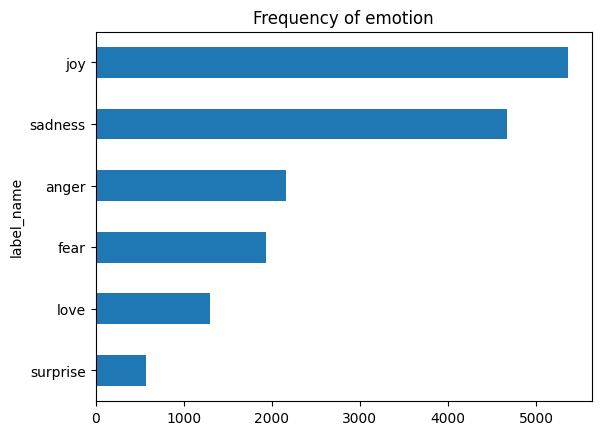

In [14]:
import matplotlib.pyplot as plt
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of emotion")
plt.show()

In [15]:
df["words per tweet"] = df["text"].str.split().apply(len)

In [16]:
df.head()

,text,label,label_name,words per tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4


In [17]:
from transformers import AutoTokenizer


In [18]:
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)


In [19]:
text = "hello my name is aditya kochhar"

In [20]:
encoded_text = tokenizer(text)
encoded_text

{'input_ids': [101, 7592, 2026, 2171, 2003, 27133, 21426, 15259, 8167, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [21]:
token = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
token

['[CLS]',
 'hello',
 'my',
 'name',
 'is',
 'adi',
 '##tya',
 'koch',
 '##har',
 '[SEP]']

In [22]:
emotion.reset_format()

In [23]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True)

In [24]:
print(tokenize(emotion["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [25]:
print(len(emotion["train"]))

16000


In [26]:
emotion_encoded = emotion.map(tokenize, batched=True, batch_size=None)
print(emotion_encoded["train"].column_names)




Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [27]:
import torch
from torch import nn

In [28]:
torch.cuda.is_available()

True

In [29]:
from transformers import AutoModel
model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
text = "this is a test"
inputs = tokenizer(text,return_tensors="pt").to(device)
print(inputs)

{'input_ids': tensor([[ 101, 2023, 2003, 1037, 3231,  102]], device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]], device='cuda:0')}


In [31]:
print(inputs['input_ids'].shape)

torch.Size([1, 6])


In [32]:
new_inputs = {}
for k,v in inputs.items():
  new_inputs[k] = v.to(device)

In [33]:
new_inputs

{'input_ids': tensor([[ 101, 2023, 2003, 1037, 3231,  102]], device='cuda:0'),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]], device='cuda:0'),
 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [34]:
with torch.no_grad():
  outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [35]:
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

In [36]:
outputs.last_hidden_state[:,0,:].size()

torch.Size([1, 768])

In [37]:
import torch

def extract_hidden_states(batch):
  inputs = {
        k: torch.tensor(v).to(device)
        for k, v in batch.items()
        if k in ["input_ids", "attention_mask"]
    }
  with torch.no_grad():
    outputs = model(**inputs).last_hidden_state[:,0,:].cpu().numpy()

  return {"hidden_states": outputs}

In [38]:
emotion_encoded.reset_format()

In [39]:
emotion_encoded.set_format("torch",columns=["input_ids","attention_mask","label"])

In [40]:
!pip install -U torch torchvision datasets


In [41]:
emotions_hidden = emotion_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

/tmp/ipykernel_3087/233621524.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  k: torch.tensor(v).to(device)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [42]:
emotions_hidden["train"].column_names

['text',
 'label',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'hidden_states']

In [43]:
device

device(type='cuda')

In [44]:
import numpy as np

In [45]:
X_train = np.array(emotions_hidden["train"]["hidden_states"])
X_valid = np.array(emotions_hidden["validation"]["hidden_states"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

In [50]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)
lr_clf.score(X_valid, y_valid)

0.634

In [48]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix


In [51]:
def plot_confusion_matrix(y_preds, y_true,labels):
  cm = confusion_matrix(y_true, y_preds,normalize='true')
  fig,ax = plt.subplots(figsize=(6,6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)
  disp.plot(cmap="Blues",values_format=".2f",ax=ax,colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

In [52]:
y_preds = lr_clf.predict(X_valid)

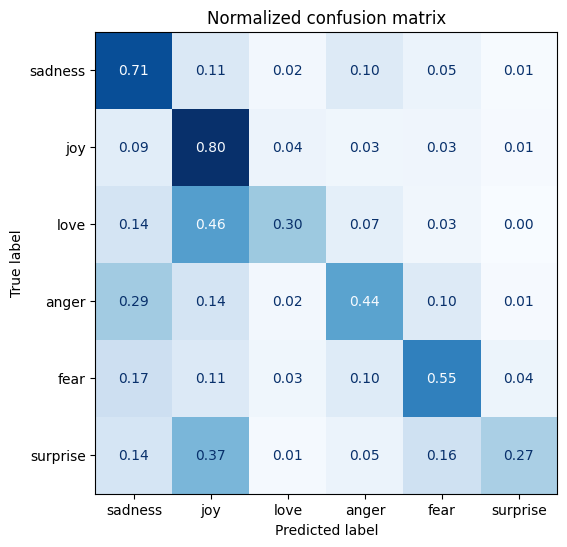

In [53]:
plot_confusion_matrix(y_preds,y_valid,emotions_hidden["train"].features["label"].names)


we will get the sequnceClassification model from hugging face that have the classificatian head on top

In [54]:
model_ckpt

'distilbert-base-uncased'

In [55]:
from transformers import AutoModelForSequenceClassification
num_label = 6
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,num_labels=num_label).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [56]:
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels,preds,average="weighted")
  acc = accuracy_score(labels,preds)
  return {"accuracy" : acc,"f1":f1}

In [57]:
from huggingface_hub import notebook_login
notebook_login()

In [58]:
print("hello")

hello


In [61]:
from transformers import TrainingArguments,Trainer
batch_size = 64
logging_steps = len(emotions_hidden["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(output_dir=model_name,num_train_epochs=2,
                                  learning_rate=2e-5,per_device_train_batch_size=batch_size,per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,disable_tqdm=False,logging_steps=logging_steps,push_to_hub=True,
                                  log_level="error",eval_strategy="epoch")

In [66]:
from transformers import Trainer

trainer = Trainer(model=model,args=training_args,compute_metrics=compute_metrics,
                  train_dataset=emotion_encoded["train"],
                  eval_dataset=emotion_encoded["validation"],
                  processing_class=tokenizer)

In [67]:
trainer.train();

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.876431,0.340138,0.902000,0.900698
2,0.273095,0.235192,0.922000,0.921637


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [68]:
pred_output = trainer.predict(emotion_encoded["validation"])

In [69]:
pred_output

PredictionOutput(predictions=array([[ 4.3722377 , -0.86564827, -1.2725576 , -0.80503374, -0.8965162 ,
        -1.4126368 ],
       [ 4.306774  , -0.9326805 , -1.5336537 , -0.6896573 , -0.61390716,
        -1.3436677 ],
       [-1.0588937 ,  1.5426351 ,  2.602311  , -0.7686506 , -1.708312  ,
        -1.2814858 ],
       ...,
       [-0.9764991 ,  3.913123  , -0.01939471, -1.1718824 , -2.0077453 ,
        -1.2510116 ],
       [-1.5154498 ,  2.3092296 ,  2.4426966 , -1.1986051 , -1.8877207 ,
        -1.0662658 ],
       [-1.283755  ,  4.0234146 , -0.25957757, -1.4607358 , -1.8181412 ,
        -0.8588898 ]], dtype=float32), label_ids=array([0, 0, 2, ..., 1, 1, 1]), metrics={'test_loss': 0.23519207537174225, 'test_accuracy': 0.922, 'test_f1': 0.9216374875144117, 'test_runtime': 4.4185, 'test_samples_per_second': 452.646, 'test_steps_per_second': 7.242})

In [70]:
y_preds = np.argmax(pred_output.predictions,axis=1)

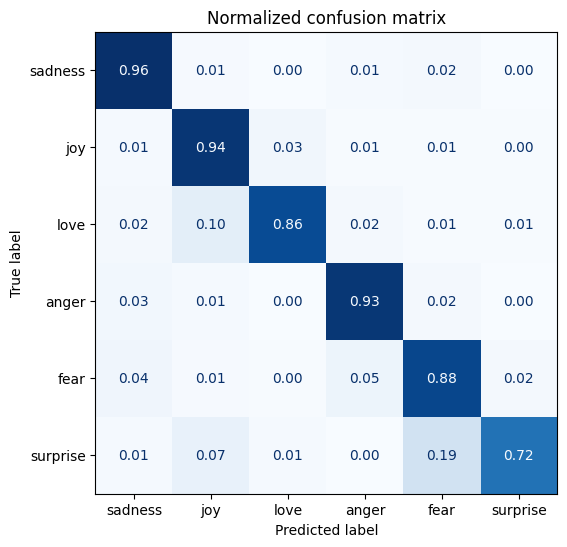

In [71]:
plot_confusion_matrix(y_preds,y_valid,emotions_hidden["train"].features["label"].names)

In [74]:
import time

In [76]:
trainer.push_to_hub(commit_message="Training completed")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...emotion/model.safetensors:  63%|######2   |  168MB /  268MB            

  ...emotion/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/UnknownPro123/distilbert-base-uncased-finetuned-emotion/commit/6efcc954615fe848a8b91ffbbdef06ca6900d74b', commit_message='Training completed', commit_description='', oid='6efcc954615fe848a8b91ffbbdef06ca6900d74b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/UnknownPro123/distilbert-base-uncased-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='UnknownPro123/distilbert-base-uncased-finetuned-emotion'), pr_revision=None, pr_num=None)

In [79]:
from transformers import pipeline



In [80]:
model_id = "UnknownPro123/distilbert-base-uncased-finetuned-emotion"
classifier = pipeline("text-classification",model=model_id)

config.json:   0%|          | 0.00/931 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

In [83]:
classifier.model.config.id2label = {
    0:'sadness',
    1:'joy',
    2:'love',
    3:'anger',
    4:'fear',
    5:'surprise'
}

In [84]:
custom_text = "i saw a movie today and it was really good"
preds = classifier(custom_text)
print(preds)

[{'label': 'joy', 'score': 0.9508034586906433}]


In [85]:
classifier.model.config.id2label

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}